Generates FigS8A

In [1]:
import numpy as np
import h5py
from scipy.io import loadmat
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from coding_model_fanofactor import population_sparsity

# Zak et al. 2020 data

In [2]:
fname = '../data/Zak_2020/Glomerular_Matrix.mat'
# f = h5py.File(fname, 'r')
resp = loadmat(fname)['Glomerular_Matrix']

#### With the matrix of 228 glomerular responses to 32 odors, the goal is to show that each odor has a handful of "private" glomeruli that can ignore the effects of backgrounds.

In [3]:
resp.shape

(228, 32)

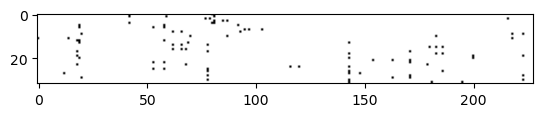

In [4]:
# find 3-glomerulus barcodes
k = 3
top_k = []
for odor in resp.T:
    top_k.append(np.argsort(odor)[-k:])
top_k = np.array(top_k)

# plt.plot(top_k[:, 0], top_k[:, 1], '.')
barcode = np.zeros(resp.T.shape)
for odor_idx in range(len(barcode)):
    barcode[odor_idx][top_k[odor_idx]] = 1
plt.figure()
plt.imshow(barcode, cmap='Grays')

In [5]:
import numpy as np
from collections import Counter

# 1. sort each pair so smaller‐first
normalized = [tuple(sorted(pair)) for pair in top_k]

# 2. count with Counter
counts = Counter(normalized)

# now counts[(a,b)] is the number of times the unordered pair {a,b} appeared
# for pair, cnt in counts.items():
#     print(f"{pair}: {cnt}")


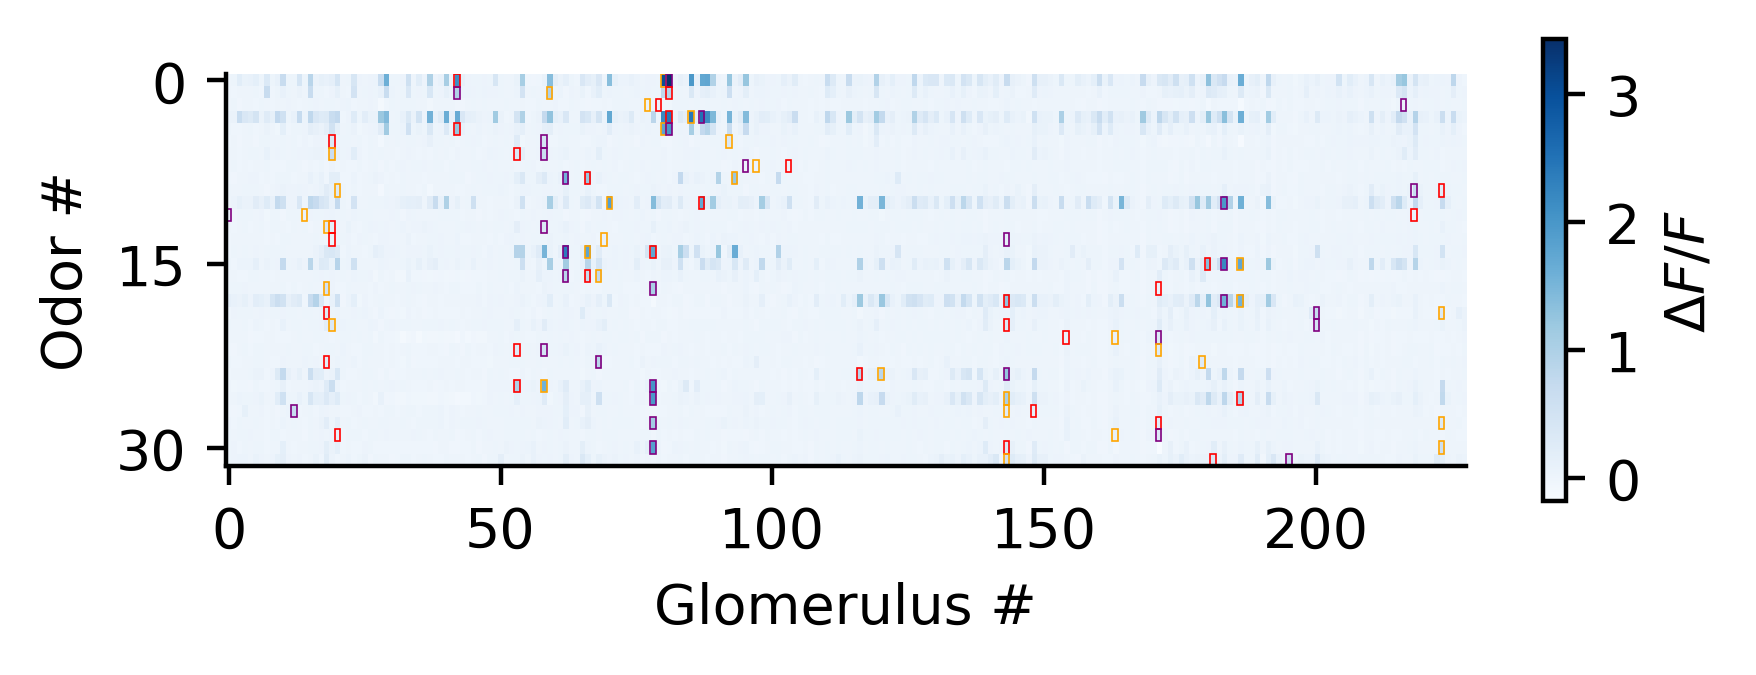

In [6]:
fig, ax = plt.subplots(figsize=(5,1.5), dpi=400)
cax = ax.imshow(resp.T, cmap='Blues', aspect=2.25)
# plt.imshow(resp.T, cmap='Blues') #, vmin=0, vmax=2.0)
fig.colorbar(mappable=cax, label='$\Delta F/F$')
ax.set_ylabel('Odor #')
ax.set_xlabel('Glomerulus #')
ax.set_yticks(np.arange(0, 32, 15))

# Coordinates to highlight (row, column)
highlight_coords = top_k
for odor_idx, top_gloms in enumerate(top_k):
    for kth_most, glom in enumerate(top_gloms):
        rect = patches.Rectangle(
            (glom - 0.5, odor_idx - 0.5),  # bottom-left corner in data coords
            1,                   # full width of one cell
            1,                   # full height of one cell
            linewidth=0.3,
            edgecolor=['r', 'orange', 'purple'][kth_most],
            facecolor='none',
            transform=ax.transData
        )
        ax.add_patch(rect)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


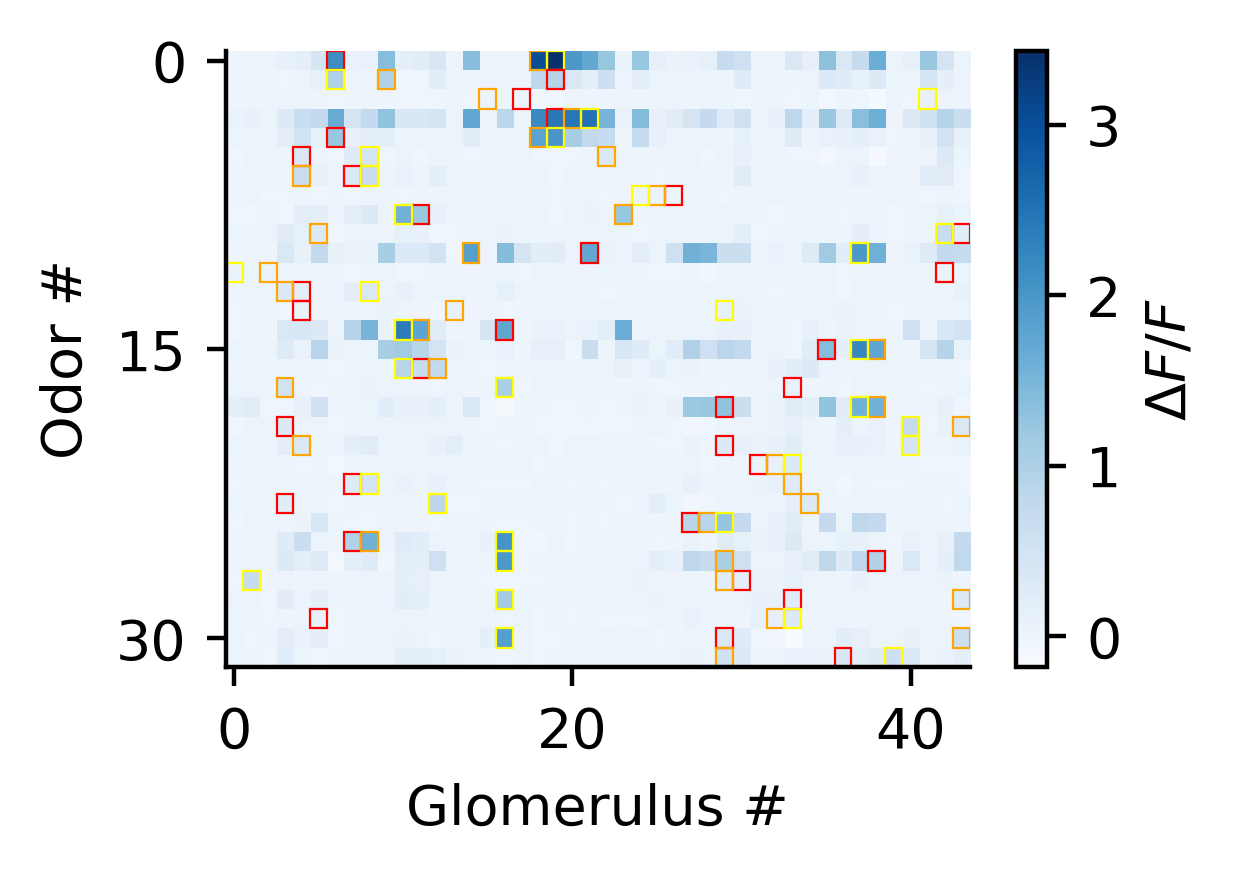

In [7]:
# --- 1) find which glomerulus‐columns actually get boxed ---
all_gloms = sorted({g for tops in top_k for g in tops})
# e.g. [0, 2, 5, 7, 9]

# --- 2) slice resp to only those gloms (rows of resp) ---
# filtered_resp: shape (len(all_gloms), n_odors)
filtered_resp = resp[all_gloms, :]

# --- 3) build a list of (odor_idx, new_glom_idx, rank) for drawing boxes ---
new_boxes = []
for odor_idx, tops in enumerate(top_k):
    for rank, old_g in enumerate(tops):
        if old_g in all_gloms:
            new_g = all_gloms.index(old_g)
            new_boxes.append((odor_idx, new_g, rank))

# --- 4) plot the trimmed heatmap & remapped boxes ---
fig, ax = plt.subplots(figsize=(3, 2), dpi=400)

# transpose so x→gloms, y→odors
cax = ax.imshow(filtered_resp.T, 
                cmap='Blues', 
                aspect='auto', 
                origin='upper')

fig.colorbar(cax, label='$\\Delta F/F$')
ax.set_xlabel('Glomerulus #')
ax.set_ylabel('Odor #')
ax.set_yticks(np.arange(0, resp.shape[1], 15))

# draw each box at (x=new_glom, y=odor)
colors = ['red','orange','yellow']
for odor_idx, new_g, rank in new_boxes:
    rect = patches.Rectangle(
        (new_g - 0.5, odor_idx - 0.5),  # x, y in data coords
        1, 1,                           # full cell size
        linewidth=0.4,
        edgecolor=colors[rank % len(colors)],
        facecolor='none',
        transform=ax.transData
    )
    ax.add_patch(rect)

# clean up spines & ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
plt.savefig('../figures/manuscript/glomerular_barcode.svg', dpi=600, bbox_inches='tight')
plt.savefig('../figures/manuscript/glomerular_barcode.png', dpi=600, bbox_inches='tight')

#### compare the population sparsity of the data with the model

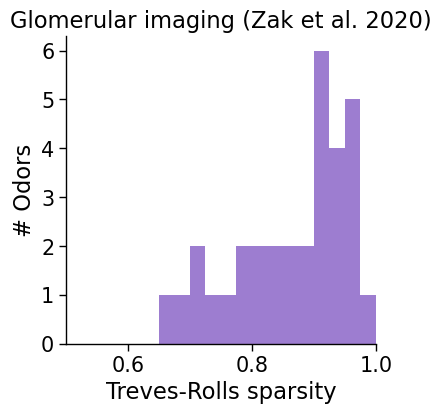

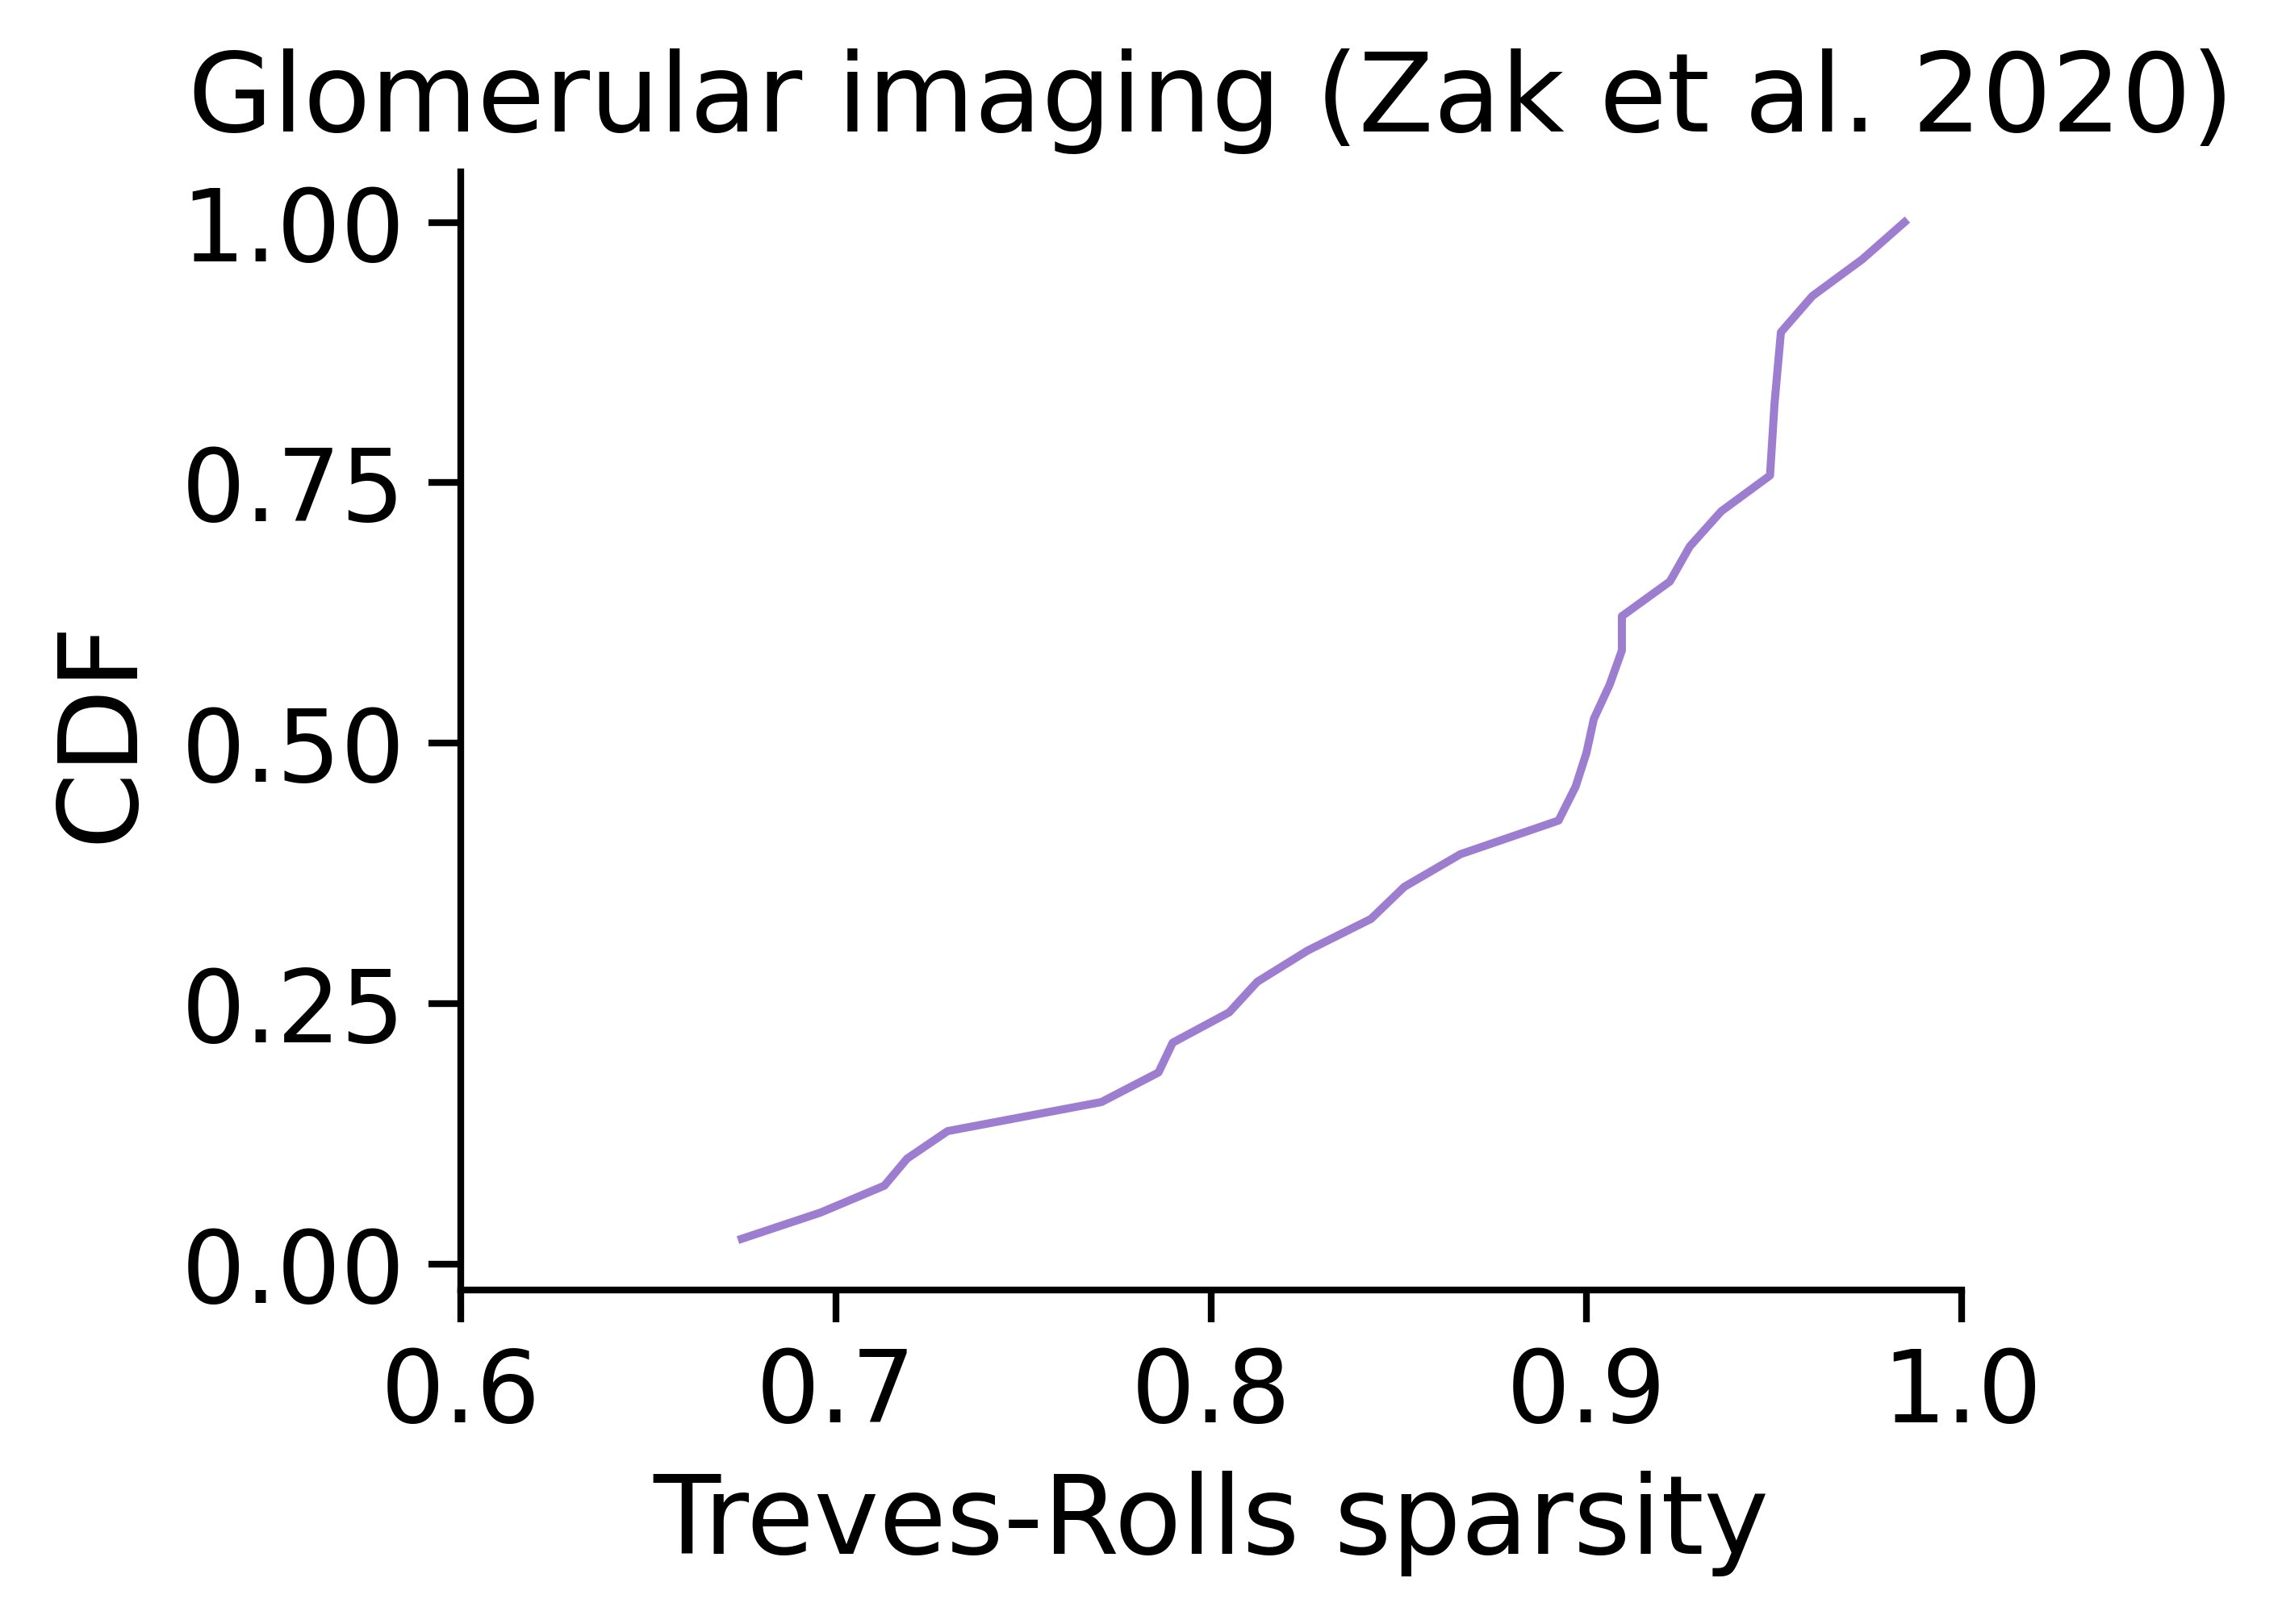

In [ ]:


sparsity = population_sparsity(np.maximum(resp, 0))
sns.set_context("paper", font_scale=1.7)  # "talk", "notebook", "paper", "poster"
plt.figure(figsize=(4,4))
plt.hist(sparsity, bins=np.arange(0.5, 1.025, 0.025),color="#9d7dd0")
plt.xlabel('Treves-Rolls sparsity')
plt.ylabel('# Odors')
plt.title('Glomerular imaging (Zak et al. 2020)')
plt.xlim(0.5, 1.)
sns.despine()
plt.savefig('../figures/manuscript/glomerular_data_sparsity.svg', dpi=600, bbox_inches='tight')
plt.savefig('../figures/manuscript/glomerular_data_sparsity.png', dpi=600, bbox_inches='tight')




185
185
185


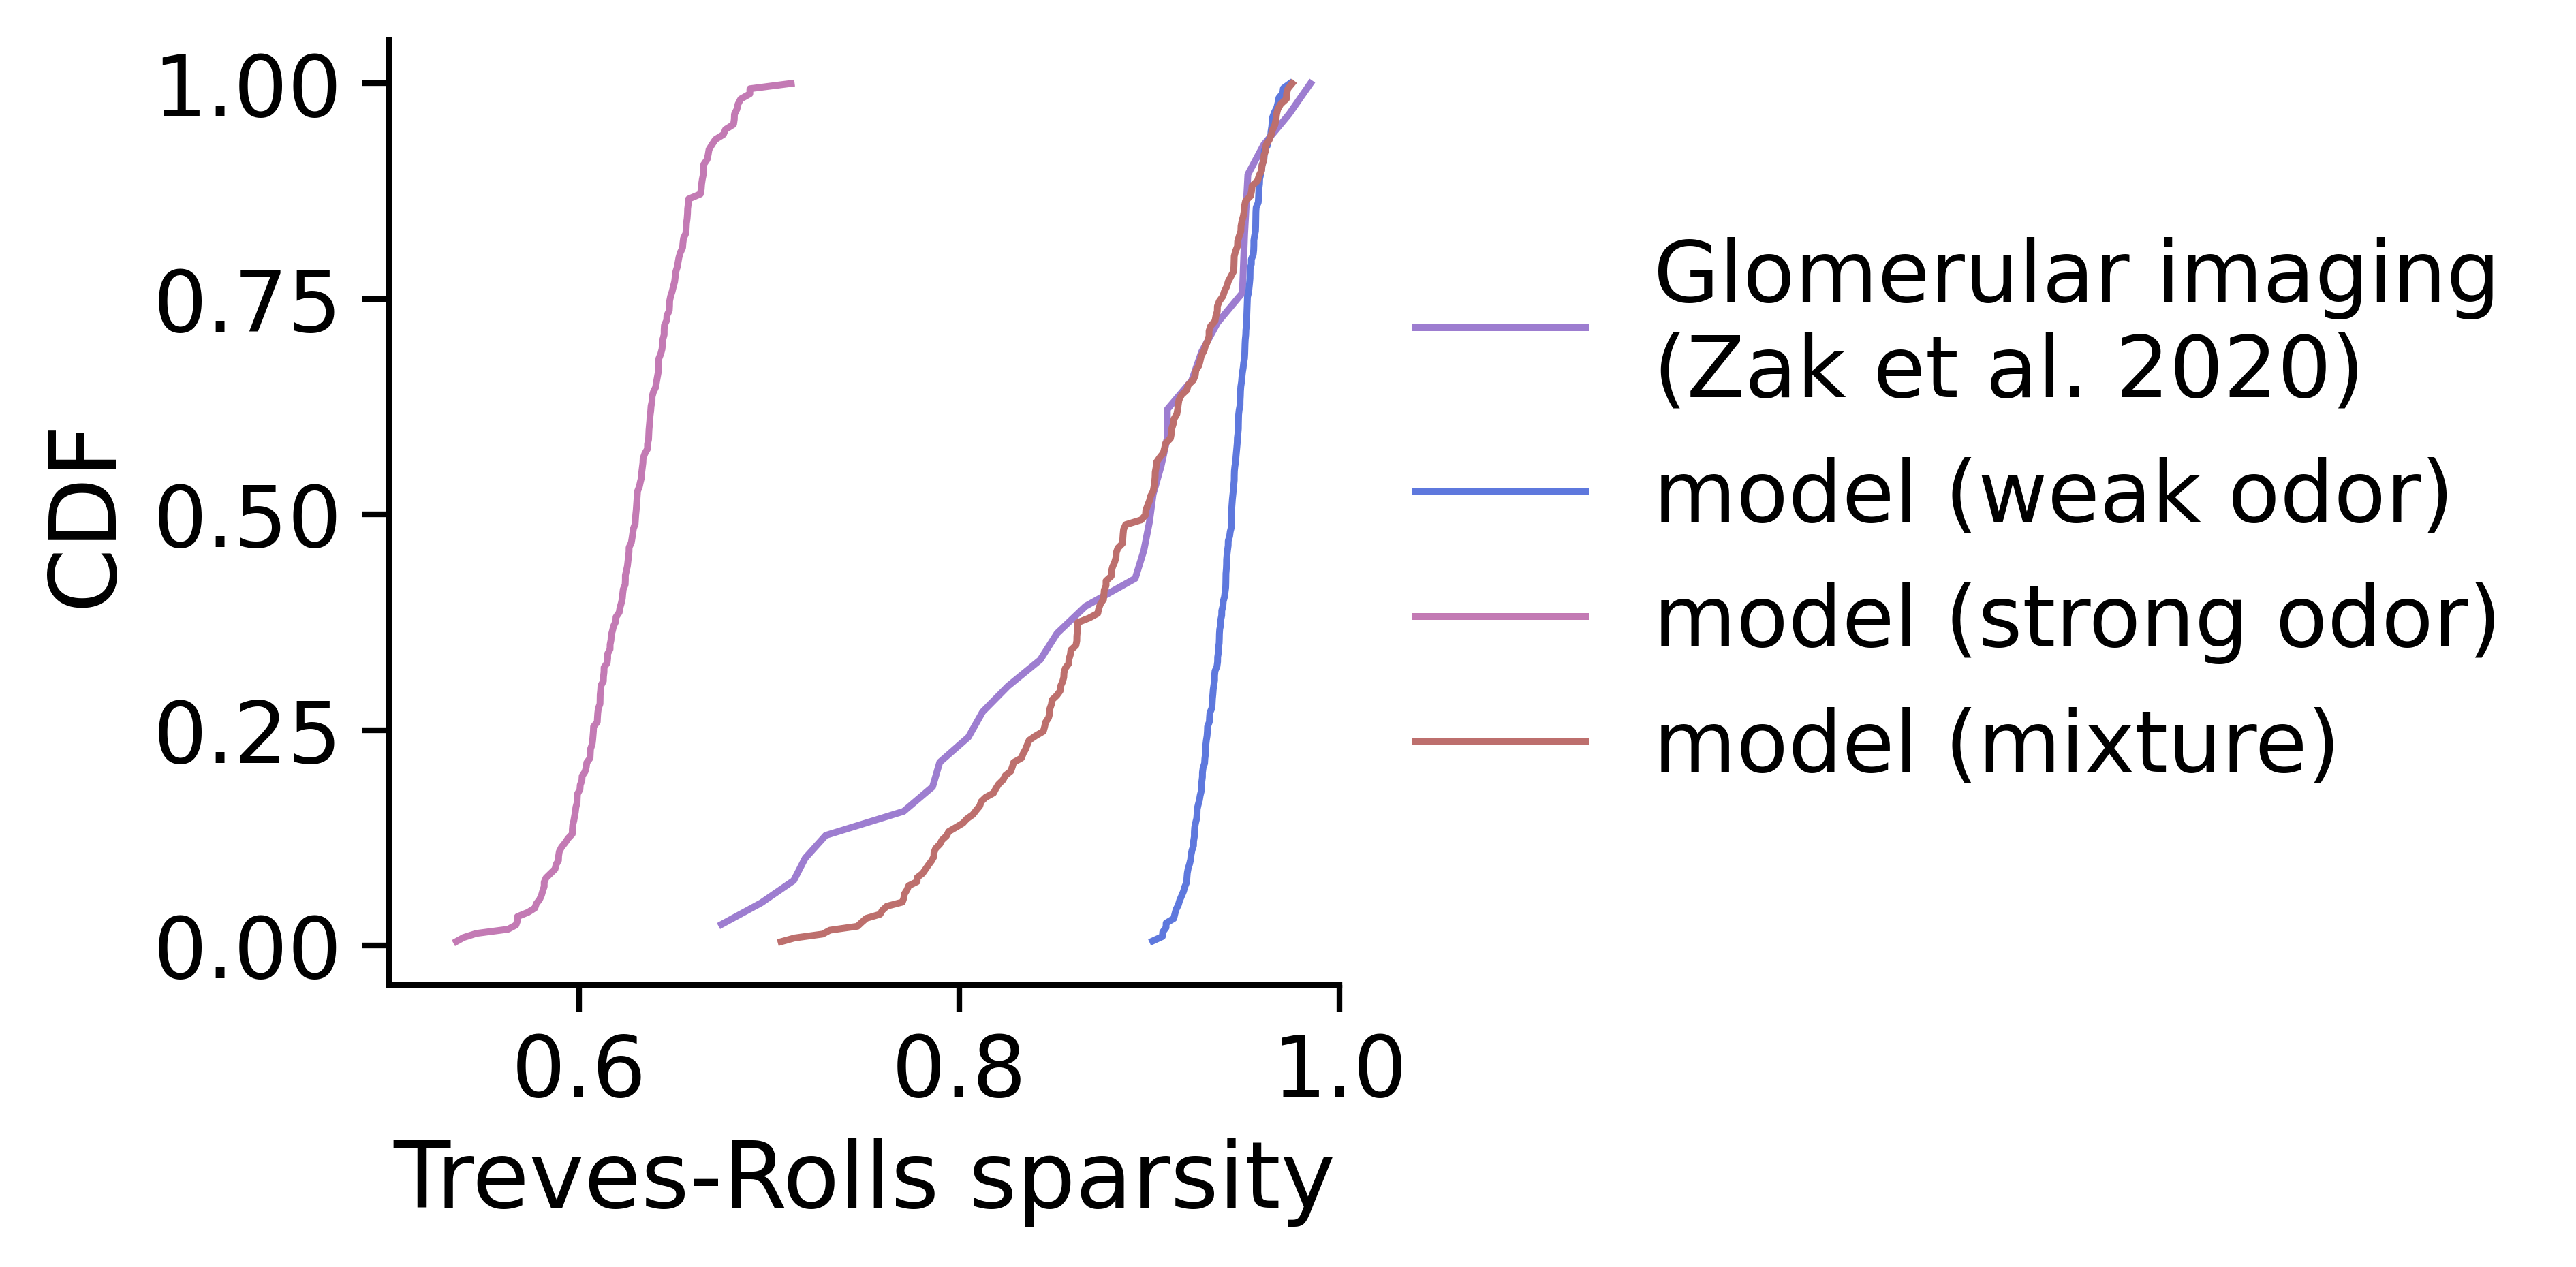

In [31]:
from coding_model_fanofactor import *
N = 20
rho = 0.5
rng = np.random.default_rng(42)
# compute population sparsity for 32 single odors
conc = 1e-3 # 1e0 # 1e-3 is weak, 1e0 is strong
n_glom_shown = 228
b = 185  # number of single odors/channels

def glom_model_sparsity(conc, n_glom_shown=228, b=185, concs=None):
    if concs is None:
        concs = np.eye(b) * conc
    conc_tensor = tensorize_concs(concs, n_samp=concs.shape[0], b=concs.shape[1], N=N)

    rng = np.random.default_rng(42)
    lnkappa = rng.standard_normal((b, N, N))
    lneta = rng.standard_normal((b, N, N))
    lneta = rho * lnkappa + np.sqrt(1 - rho * rho) * lneta
    lnkappa = -4 * lnkappa
    kappa = np.exp(lnkappa)
    eta = np.exp(lneta)

    inv_kappa = 1.0 / kappa
    F_max = 1
    hill_n = 4

    r = compute_activity_vec(
    conc_tensor,
    kappa,
    eta,
    F_max=F_max,
    n=hill_n,
    sigma=0.0,
    inv_kappa=inv_kappa,
    fano_factor_one=False,
    ).reshape(concs.shape[0], -1)[:, :n_glom_shown]

    norm_r = r / r.max(axis=0, keepdims=True) # normalize responses by maximum response across odors
    model_sorted_sparsity = sorted(population_sparsity(norm_r.T), reverse=False)
    print(len(model_sorted_sparsity))
    model_cum_frac = np.cumsum(model_sorted_sparsity) / np.sum(model_sorted_sparsity)
    return model_sorted_sparsity, model_cum_frac

weak_sparsity, weak_cdf = glom_model_sparsity(1e-3)
strong_sparsity, strong_cdf = glom_model_sparsity(1.0)
mixture_sparsity, mixture_cdf = glom_model_sparsity(conc=0, concs=np.diag(np.logspace(-3.5, -1, b)))


plt.figure(figsize=(3,3), dpi=600)
sorted_sparsity = np.sort(sparsity)
cum_frac = np.cumsum(sorted_sparsity) / sorted_sparsity.sum()

plt.plot(sorted_sparsity, cum_frac, color="#9d7dd0", label="Glomerular imaging\n(Zak et al. 2020)")
plt.plot(weak_sparsity, weak_cdf, color=  "#5e78dd", label="model (weak odor)")
plt.plot(strong_sparsity, strong_cdf, color= "#c37ab4", label="model (strong odor)")
plt.plot(mixture_sparsity, mixture_cdf, color= "#bd6f6d", label="model (mixture)")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
plt.xlabel('Treves-Rolls sparsity')
plt.ylabel('CDF')
# plt.title('Glomerular imaging (Zak et al. 2020)')
plt.xlim(0.5, 1.)
sns.despine()
# plt.savefig('../figures/manuscript/glomerular_data_sparsity_cdf.svg', dpi=600, bbox_inches='tight')
# plt.savefig('../figures/manuscript/glomerular_data_sparsity_cdf.png', dpi=600, bbox_inches='tight')